IMPORTS

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
#this is our main stats library
from statsmodels.tsa.arima.model import ARIMA

FITTING ARIMA ONTO DATA

In [2]:
#paste your correct path below
btc_path = Path(r"spot_5m.parquet")
df = pd.read_parquet(btc_path)
df.head()

,timestamp,datetime,open,high,low,close,volume,exchange,market_type
0,1502942400000,2017-08-17 04:00:00+00:00,4261.48,4280.56,4261.48,4261.48,2.189061,binance,spot
1,1502942700000,2017-08-17 04:05:00+00:00,4261.48,4261.48,4261.48,4261.48,0.000000,binance,spot
2,1502943000000,2017-08-17 04:10:00+00:00,4261.48,4261.48,4261.48,4261.48,0.000000,binance,spot
3,1502943300000,2017-08-17 04:15:00+00:00,4261.48,4264.88,4261.48,4261.48,0.484666,binance,spot
4,1502943600000,2017-08-17 04:20:00+00:00,4264.88,4266.29,4264.88,4266.29,2.328570,binance,spot


In [3]:
#let us clean the data
df.dropna(inplace=True)
df.drop(columns=['timestamp', 'open', 'high', 'low', 'volume','exchange','market_type'], inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)
df.head()

,close
datetime,
2017-08-17 04:00:00+00:00,4261.48
2017-08-17 04:05:00+00:00,4261.48
2017-08-17 04:10:00+00:00,4261.48
2017-08-17 04:15:00+00:00,4261.48
2017-08-17 04:20:00+00:00,4266.29


In [4]:
# --- OPTIONAL: RESAMPLE 5-MIN DATA TO 1-HOUR (UNCOMMENT TO USE) ---

#df = df['close'].resample('1h').last().dropna().to_frame(name='close')

#print(df.head())
#print(len(df))

In [5]:
# the ARIMA model requires a univariate time series, so we will use the 'close' price
# datetime is not strictly necessary once the data is properly ordered, but it is good practice to keep it as the index for time series data
series = df['close']

In [6]:
#now we specify and run the model. Note that this may take a while to run, especially if our dataset is large as the one used in this case
model = ARIMA(series, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

/opt/anaconda3/envs/minai/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/minai/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/minai/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               894382
Model:                 ARIMA(1, 1, 1)   Log Likelihood            -5226042.734
Date:                Fri, 03 Apr 2026   AIC                       10452091.469
Time:                        08:22:39   BIC                       10452126.581
Sample:                             0   HQIC                      10452101.175
                             - 894382                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5877      0.005    108.828      0.000       0.577       0.598
ma.L1         -0.6107      0.005   -114.900      0.000      -0.621      -0.600
sigma2      6963.8835      1.091   6385.490      0.0

Interpret the results. We are most interested in ar.L1 and ma.L1 coefficients and their pvalues. The AR coefficient informs us about persistence, while the MA coefficient captures how the series reacts to past forecast errors.

In the case of BTC, a negative MA coefficient suggests that positive forecast errors tend to be followed by offsetting adjustments, and vice versa. A positive AR coefficient suggests persistence, meaning recent changes are more likely to be followed by changes in the same direction. These coefficients can be used to generate forecasts for future observations using only information available up to the forecast time.

Now let us see how to make a simple strategy using that: if the predicted next price is above the latest observed price, enter long. If the predicted next price is below the latest observed price, enter short. For our purposes, we fit ARIMA on data from 2019 to 2021 and then run our strategy on data from 2022 to 2026.

PRICE PREDICTION STRATEGY

In [7]:
series2 = df.loc['2019':'2021', 'close']
series2.head()
print(len(series2))

314846


In [8]:
model_2 = ARIMA(series2, order=(1, 1, 1))
model_2 = model_2.fit()
print(model_2.summary())

/opt/anaconda3/envs/minai/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/minai/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/minai/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               314846
Model:                 ARIMA(1, 1, 1)   Log Likelihood            -1817157.748
Date:                Fri, 03 Apr 2026   AIC                        3634321.496
Time:                        08:23:59   BIC                        3634353.475
Sample:                             0   HQIC                       3634330.726
                             - 314846                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1365      0.006     23.202      0.000       0.125       0.148
ma.L1         -0.1814      0.006    -30.815      0.000      -0.193      -0.170
sigma2      6035.0598      1.771   3407.365      0.0

The coefficients are different - as expected, since this ARIMA process was fit on a subsample and the dynamics are different. The 2019-2021 period saw both the pandemic and the crypto bull market.

In [9]:
#remember to store your coefficients if you want to use them for forecasting or other purposes
ar1 = model_2.params['ar.L1']
ma1 = model_2.params['ma.L1']
#check if they are what we see above
print(ar1)
print(ma1)

0.13654949017263038
-0.18136224346438992


Now we will build a simple backtesting engine and forecast prices 1 period ahead (5 minutes in our case). Additionally, we will set a threshold above which our predicted return should be so that we don't trade noise. For simplicity, we keep the AR and MA coefficients fixed from the training sample and update only residuals through time. In practice, a more robust implementation would periodically re-estimate the model.

In [10]:
test = df.loc['2022':'2026', 'close'].copy()

In [11]:
diff = test.diff().dropna()

In [12]:
predictions = []
signals = []
residuals = [0]   # we start with 0

threshold = 0.0005  #example noise filter for this high-frequency data

In [13]:
for i in range(1, len(diff)):
    
    prev_diff = diff.iloc[i-1]
    prev_resid = residuals[-1]
    
    # ARMA prediction of price change
    pred_diff = ar1 * prev_diff + ma1 * prev_resid
    
    # convert back to price level
    prev_price = test.iloc[i]
    pred_price = prev_price + pred_diff
    
    predictions.append(pred_price)
    
    # actual next price
    actual_price = test.iloc[i+1] if i+1 < len(test) else test.iloc[i]
    
    # compute residual
    resid = actual_price - pred_price
    residuals.append(resid)
    
    # signal
    predicted_return = (pred_price - prev_price) / prev_price
    
    if predicted_return > threshold:
        signal = 1
    elif predicted_return < -threshold:
        signal = -1
    else:
        signal = 0
    
    signals.append(signal)

In [14]:
results = pd.DataFrame({
    'price': test.iloc[2:].values,   # <-- shift by 2
    'prediction': predictions,
    'signal': signals
}, index=test.index[2:])

In [15]:
results['market_return'] = results['price'].pct_change()

results['strategy_return'] = (
    results['signal'].shift(1) * results['market_return']
)

results['strategy_return'] = results['strategy_return'].fillna(0)

In [16]:
cost_per_trade = 0 #change this value to see how alpha is affected by trading costs

results['position_change'] = results['signal'].diff().abs().fillna(0)
results['trading_cost'] = results['position_change'] * cost_per_trade

results['net_return'] = results['strategy_return'] - results['trading_cost']

In [17]:
initial_capital = 10000

results['strategy_equity'] = (
    initial_capital * (1 + results['net_return']).cumprod()
)

results['buy_hold_equity'] = (
    initial_capital * (1 + results['market_return'].fillna(0)).cumprod()
)

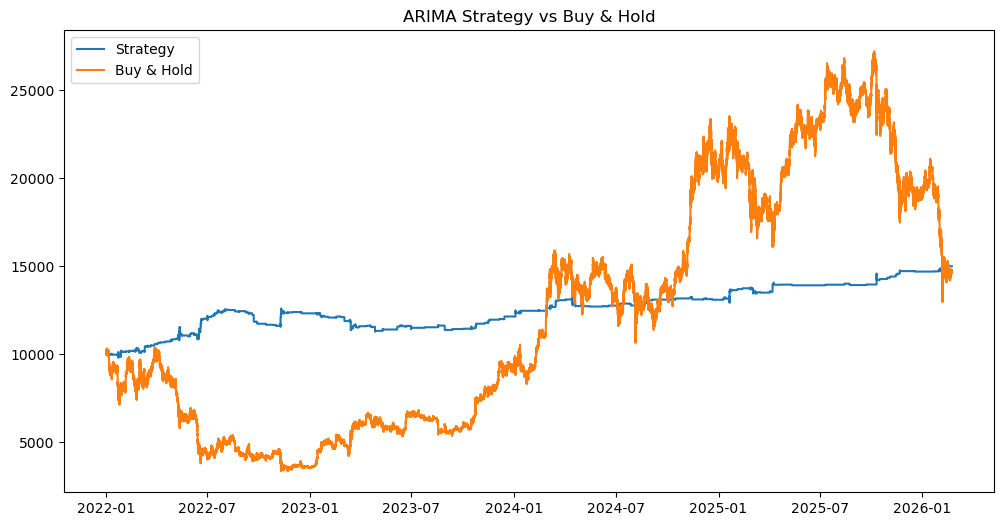

In [18]:
plt.figure(figsize=(12,6))
plt.plot(results.index, results['strategy_equity'], label='Strategy')
plt.plot(results.index, results['buy_hold_equity'], label='Buy & Hold')
plt.legend()
plt.title('ARIMA Strategy vs Buy & Hold')
plt.show()

In [19]:
# --- PERFORMANCE METRICS ---

import numpy as np

# --- Total PnL ---
initial_capital = 10000
final_capital = results['strategy_equity'].iloc[-1]

total_pnl = final_capital - initial_capital
total_return = final_capital / initial_capital - 1

# --- Max Drawdown ---
equity = results['strategy_equity']
running_max = equity.cummax()
drawdown = (equity - running_max) / running_max
max_drawdown = drawdown.min()

# --- Sharpe Ratio ---
returns = results['net_return'].dropna()

# annualization factor (5-min data ≈ 288*365 periods/year)
# if using 1-hour data → change to 24*365
periods_per_year = 288 * 365

if len(returns) == 0 or returns.std() == 0:
    sharpe = np.nan
else:
    sharpe = (returns.mean() / returns.std()) * np.sqrt(periods_per_year)

# --- Create nice table ---
metrics = pd.DataFrame({
    'Metric': [
        'Total PnL ($)',
        'Total Return (%)',
        'Max Drawdown (%)',
        'Sharpe Ratio'
    ],
    'Value': [
        total_pnl,
        total_return * 100,
        max_drawdown * 100,
        sharpe
    ]
})

# formatting
metrics['Value'] = metrics['Value'].apply(
    lambda x: round(x, 4) if pd.notna(x) else 'N/A'
)

metrics.set_index('Metric', inplace=True)

metrics

,Value
Metric,
Total PnL ($),4996.7134
Total Return (%),49.9671
Max Drawdown (%),-10.3804
Sharpe Ratio,1.1876


In [20]:
num_trades = (results['position_change'] > 0).sum()
print("Number of trades:", num_trades)

Number of trades: 1274


Try to change the values of the threshold and fees. In general, the threshold should be large enough to justify trading costs. Otherwise, the strategy may take trades where the expected edge is smaller than the cost of execution. Lastly, you can change the dataset you use in order to run the ARIMA on other assets and timeframes. 